# CVineMarketGen — Example 2: macro factors from point-in-time market data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/example_factors.ipynb)

Six monthly factor excess returns (Equity DM, Equity EM, Real premia, Inflation, Credit,
Commodity) built at run time from public market series (Fama-French, FRED, Yahoo
Finance), with **no target other than the history itself**: the sample mean, volatility,
skewness, kurtosis and correlation matrix are the targets, and the copula families are
selected on the same sample (Algorithm 3 of the paper *Vine-Copula Based Financial
Market Simulation with Moment and Tail Dependence Targeting*, thesis, article 3). The
vine is then **calibrated** (Algorithm 4) and a scenario matrix is **simulated**
(Algorithm 5); the **Fleishman + Vale-Maurelli** generator is run on the same targets,
and the exceedance-correlation curves are compared with the actual factor history.

No data file is shipped with the package; the download is cached locally. Seeded and
reproducible; runtime on a laptop about 3 minutes. See also
[`example_ltcma.ipynb`](example_ltcma.ipynb) for the LTCMA-targeting example.

In [1]:
import os, sys, time, warnings, io, contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # allows running from a local clone (from examples/ or the root)

try:
    import cvinemarketgen                 # local clone or already installed
except ImportError:                       # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git"], check=True)
    import cvinemarketgen

from cvinemarketgen import CVineGenerator, FleishmanGenerator

RAW = "https://raw.githubusercontent.com/mamadouyamar/CVineMarketGen/main/data/"
def load_targets(name):
    path = os.path.join(ROOT, "data", name)
    return pd.read_csv(path if os.path.exists(path) else RAW + name, index_col="Assets")

N_HIST = 3000      # length of the synthetic "historical" series
N_OPT  = 10000     # draws used inside the correlation-targeting optimizer (paper: 20000)
N_SIM  = 25000     # scenarios in the final simulated matrix (paper: 25000)
CORR_TOL = 5e-2    # acceptance tolerance on pairwise correlations (paper: 2e-2 with N_OPT = 20000)
SEED = 1

def make_generator():
    return CVineGenerator(tol_opt=1e-10, n_samples=N_OPT,
                          use_ncs_on_firsttree=False, use_ncs_on_deepertrees=False,
                          use_mixture_on_firsttree=True, use_mixture_on_deepertrees=False,
                          force_try_ncscopula=False, tol_for_optimization_func=1e-6)

def show_moments(name, cal, t):
    print(f"== {name}  (N={N_SIM}, {t:.0f}s) ==")
    cols = ['mean (target)', 'mean (calibrated)', 'volatility (target)', 'volatility (calibrated)',
            'skewness (target)', 'skewness (calibrated)', 'kurtosis (target)', 'kurtosis (calibrated)']
    print(cal[cols].round(4).to_string())
    print("max |diff| mean, vol, skew, kurt:",
          [f"{cal[c].abs().max():.1e}" for c in ['diff mean', 'diff volatility', 'diff skewness', 'diff kurtosis']])

def show_corr(name, target, sim):
    d = (sim.corr().values - target.values) * 100
    lo = d[np.tril_indices(len(target), -1)]
    print(f"{name}: correlation error in percentage points -> max |.| {np.abs(lo).max():.2f}, mean |.| {np.abs(lo).mean():.2f}")

def plot_exceedance(gen, base, others, series, targets, ncols=3, zlim=1.0):
    z = np.arange(-zlim, zlim + 0.025, 0.05)
    n = len(others); nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows), squeeze=False)
    style = {'Historical': dict(color='black', lw=2), 'C-vine': dict(color='tab:blue', lw=1.6),
             'Fleishman': dict(color='tab:orange', lw=1.6, ls='--')}
    for ax, a in zip(axes.flat, others):
        for name, df in series.items():
            ax.plot(z, gen.exceedance_correlation(df[base].values, df[a].values, z), label=name, **style[name])
        ax.axvline(0, color='grey', lw=0.6, ls=':'); ax.axhline(targets.loc[base, a], color='grey', lw=0.6, ls=':')
        ax.set_title(f"{base} vs {a}  (target {targets.loc[base, a]:+.2f})", fontsize=9)
        ax.set_xlabel(f"threshold on {base} (std)", fontsize=8); ax.tick_params(labelsize=8); ax.grid(alpha=0.25)
    for ax in axes.flat[n:]:
        ax.axis('off')
    h, l = axes.flat[0].get_legend_handles_labels()
    fig.legend(h, l, loc='lower center', ncol=3, frameon=False); fig.tight_layout(rect=(0, 0.05, 1, 1)); plt.show()

quiet = lambda: contextlib.redirect_stdout(io.StringIO())   # silences the pipeline's progress prints

print("setup done")

setup done


## Example 2 — Macro factors from point-in-time market data (6 factors)

Here there is **no target other than the history**: the sample mean, volatility,
skewness, kurtosis and correlation matrix of six monthly factor excess returns are the
targets, and the copula families are selected on the same sample. The question is
whether each generator reproduces this factor history, tails included.

The factors are built at run time from public market series (nothing is shipped with
the package; `load_factor_data` caches the download in `data/factors_cache.csv`):

| Factor | Construction | Source |
|---|---|---|
| Equity DM | developed-market excess return, Mkt-RF | Fama-French, Developed 3 factors |
| Equity EM | emerging minus developed excess return | Fama-French, Emerging 5 factors minus Developed |
| Real premia | long TIPS / short cash: carry − 8 × change of the 10y TIPS real yield (DFII10) | FRED |
| Inflation | long TIPS / short nominal: carry + 8 × change of the 10y breakeven (T10YIE) | FRED |
| Credit | long Baa corporates / short Treasuries: carry − 10 × change of the Baa − 10y spread (BAA10Y) | FRED |
| Commodity | DBC commodity ETF total return minus the risk-free rate | Yahoo Finance |

The yield-based factors are duration-scaled proxies (Duration-Times-Spread
decomposition for the credit leg); Moody's Baa index is long-maturity, hence the
duration of 10. Equity DM is the central node of the C-vine.

In [2]:
from cvinemarketgen import load_factor_data, factor_targets

factors_ret = load_factor_data(start="2006-03", cache=os.path.join(ROOT, "data", "factors_cache.csv"))   # monthly excess returns, decimal
factors = list(factors_ret.columns)
mf = factor_targets(factors_ret)                          # targets = the sample itself (monthly units)
mf_corr = mf[factors]
print()
print(pd.concat([mf[['Arithmetic Mean', 'Volatility']].mul([12, 12 ** 0.5]).rename(columns={'Arithmetic Mean': 'mean (ann.)', 'Volatility': 'vol (ann.)'}),
                 factors_ret.skew().rename('skewness'), (factors_ret.kurtosis() + 3).rename('kurtosis')], axis=1).round(3).to_string())
print("\ncorrelation matrix:"); print(mf_corr.round(2).to_string())

factor data read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/factors_cache.csv: 244 months, 2006-04 to 2026-07

             mean (ann.)  vol (ann.)  skewness  kurtosis
Equity DM          0.080       0.158    -0.641     4.735
Equity EM         -0.007       0.108    -0.024     2.987
Real premia        0.008       0.062    -0.633     5.405
Inflation          0.020       0.047     0.133     9.561
Credit             0.025       0.082    -1.910    17.585
Commodity          0.023       0.188    -0.531     4.963

correlation matrix:
             Equity DM  Equity EM  Real premia  Inflation  Credit  Commodity
Assets                                                                      
Equity DM         1.00       0.10         0.30       0.51    0.61       0.51
Equity EM         0.10       1.00         0.13       0.18    0.21       0.25
Real premia       0.30       0.13         1.00       0.21   -0.02       0.11
Inflation         0.51       0.18         0.21     

### Family selection, calibration and simulation

Same calls as in Example 1, with the factor history in place of the synthetic one.
The family selected for each edge is what Algorithm 3 reads from the exceedance
curves of the sample.

In [3]:
gen_mf = make_generator()
np.random.seed(SEED)
t0 = time.time()
with quiet():
    setup_mf = gen_mf.load_data_and_setup(mf, factors_ret, factors)
    fit_mf = gen_mf.fit_and_structure_CVine(setup_mf)
print(f"selection done in {time.time() - t0:.0f}s")
print(gen_mf.selected_edge_table(factors, fit_mf).to_string(index=False))

t0 = time.time()
with quiet():
    vine_mf = gen_mf.run_vine_optimization(setup_mf, fit_mf)
    sims_mf, cals_mf, _ = gen_mf.run_multi_year_simulation(vine_mf, n_year=1, n_per_year=N_SIM, corr_tol=CORR_TOL)
cal_mf = cals_mf[0]
t_mf = time.time() - t0
vine_sim_mf = sims_mf[0]
print(f"\ncalibration + simulation done in {t_mf:.0f}s\n")
print(gen_mf.selected_edge_table(factors, fit_mf, vine_mf).to_string(index=False)); print()
show_moments("C-vine, 6 factors", cal_mf, t_mf)
show_corr("C-vine", mf_corr, vine_sim_mf)

selection done in 6s
 tree                                                              edge selected family   parameters
    1                                             Equity EM , Equity DM     gumbel 180°  theta=1.069
    1                                           Real premia , Equity DM     gumbel 180°  theta=1.234
    1                                             Inflation , Equity DM     gumbel 180°  theta=1.573
    1                                                Credit , Equity DM     gumbel 180°  theta=1.673
    1                                             Commodity , Equity DM     gumbel 180°  theta=1.499
    2                               Real premia , Equity EM | Equity DM    clayton 180°  theta=0.152
    2                                 Inflation , Equity EM | Equity DM    clayton 180°  theta=0.183
    2                                    Credit , Equity EM | Equity DM       gumbel 0°  theta=1.092
    2                                 Commodity , Equity EM | Equity D

### Fleishman benchmark and exceedance correlation

The curves now compare the two generators with the **actual factor history**.

pairs without a real Vale-Maurelli root: 0
Fleishman max |error| mean, vol, skew, kurt: ['1.3e-17', '1.1e-06', '2.2e-11', '8.6e-11']
Fleishman: correlation error in percentage points -> max |.| 1.29, mean |.| 0.49


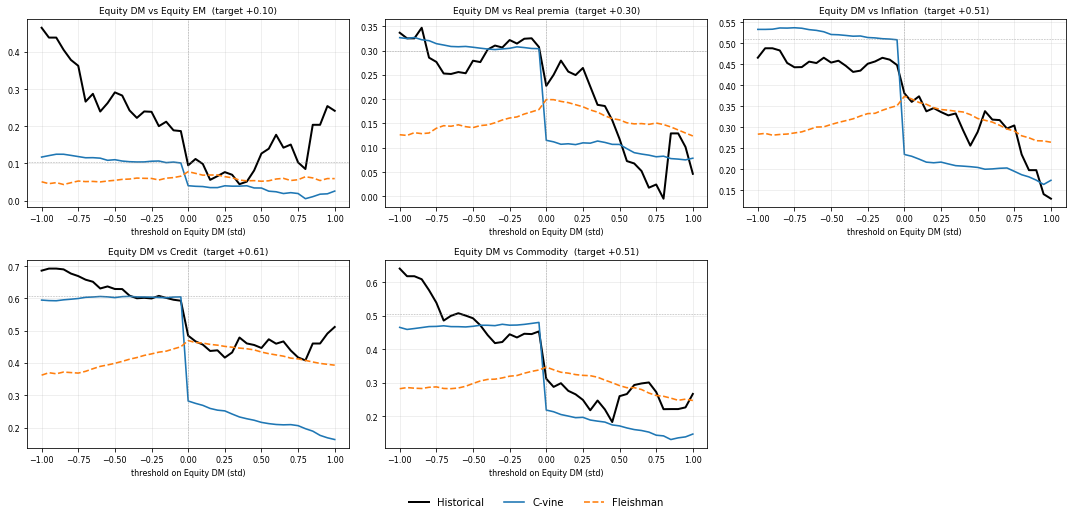

In [4]:
ts_mf = setup_mf['df_target_stats']
fg_mf = FleishmanGenerator()
out_mf = fg_mf.fit(ts_mf['Arithmetic Mean'], ts_mf['Volatility'], ts_mf['Skewness'], ts_mf['Kurtosis'] - 3, setup_mf['ltcma_corr'])
print("pairs without a real Vale-Maurelli root:", len(out_mf['infeasible_pairs']))
fleish_sim_mf, ferr_mf, _ = fg_mf.simulate(N_SIM, corr_tol=CORR_TOL, seed=SEED, verbose=False)
print("Fleishman max |error| mean, vol, skew, kurt:", [f"{ferr_mf[k]:.1e}" for k in ['mean', 'vol', 'skew', 'kurt']])
show_corr("Fleishman", mf_corr, fleish_sim_mf)
plot_exceedance(gen_mf, factors[0], factors[1:], {'Historical': factors_ret, 'C-vine': vine_sim_mf, 'Fleishman': fleish_sim_mf}, mf_corr)

### Reading the results

- **Moments**: both generators re-fit their marginal parameters on the accepted draw, so
  the four moments are matched by construction.
- **Correlations**: both generators reach the targets within `CORR_TOL`. The Fleishman
  generator is usually closer, since the Vale-Maurelli step solves each pairwise
  equation exactly; the C-vine generator matches the correlations numerically under
  the constraint of the selected families.
- **Tail dependence**: only the C-vine generator reproduces the shape of the
  exceedance-correlation curves (jump at zero, and a sign change wherever a mixture is selected). The
  Fleishman generator inherits the Gaussian copula of its underlying normal vector,
  whose curves are smooth and symmetric.
- **No synthetic truth here**: the selected families are what the exceedance
  curves of 244 months of factor returns support (a Gumbel 180°, lower-tail dependence,
  on every first-tree edge), and the figure shows how far each generator reproduces
  them. The C-vine reproduces the jump at zero on all five pairs; it undershoots on the
  right side for Credit and Inflation, and the rise of the Equity EM curve deep in the
  left tail is stronger than a Gumbel constrained to a target correlation of 0.10 can
  produce. The 2008 episode makes the credit factor extremely heavy-tailed (kurtosis
  above 17), which both marginal models accommodate, at the cost of the largest
  skewness and kurtosis errors of the notebook (about 1e-2, within the 5e-2 tolerance).

Reference: thesis, article 3, *Vine-Copula Based Financial Market Simulation with
Moment and Tail Dependence Targeting*, Sections 3 to 5 and Appendix C.